# LIF Microscopy Analysis Notebook
### Interactive Workflow for Leica Confocal `.lif` Files

**Author:** Demirer Lab — CIS Project workflow
**Purpose:** Load one `.lif` file or a whole folder of `.lif` files, assign fluorescence channels, perform manual nuclear click-counting alongside parallelized automated cytosol segmentation, and export structured QC images and a final CSV.

---

## Quick-start
1. Edit the `CONFIG` cell (cell 3) — set `input_path`, `output_dir`, and `default_mode`.
2. Run **all cells** top to bottom once to initialize classes and the background worker.
3. The interactive viewer widget launches automatically in the **Launch Workflow** cell.
4. Click on nuclei to count; automated cytosol jobs run in the background.
5. When done, run the **Final CSV Export** cell.

---

## Analysis modes

| Mode | Nuclear counting | Cytosol counting |
|------|-----------------|-----------------|
| **Protoplast** | Manual click (yellow) | Automated — Cellpose `cyto3` |
| **Epidermal** | Manual click (yellow) | Automated — Cellpose `cyto3` (large diameter) + watershed fallback |
| **Manual** | Manual click (yellow) | Manual click (magenta) |

---

## Pseudocolor convention (mandatory, used in viewer AND saved QC images)

| Channel | Pseudocolor | RGB formula |
|---------|-------------|-------------|
| Nucleus | **Yellow** | R = G = intensity; B = 0 |
| Cytosol | **Magenta** | R = B = intensity; G = 0 |

---

## Key files from example data

| File | Mode | Nucleus ch | Cytosol ch | Series | Channels | Scale |
|------|------|-----------|-----------|--------|----------|-------|
| `c51-1.lif` | Epidermal | C=2 | C=0 | 8 | 4 | 1.768 µm/px |
| `500nguL-1.lif` | Protoplast | C=0 | C=2 | 10 | 3 | 1.322 µm/px |


## Notebook Architecture

```
┌────────────────────────────────────────────────────────────────┐
│  LIFWorkflowApp  (main widget controller)                      │
│  ┌─────────────┐  ┌────────────────┐  ┌─────────────────────┐ │
│  │  LifLoader  │  │  ImageViewer   │  │  BackgroundJobQueue │ │
│  │  (readlif)  │  │  (matplotlib   │  │  (ThreadPoolExec.)  │ │
│  └─────────────┘  │   + ipywidgets)│  └─────────┬───────────┘ │
│  ┌─────────────┐  └────────────────┘            │             │
│  │  Manual     │  ┌────────────────┐  ┌─────────▼───────────┐ │
│  │  Counter    │  │  QCExporter    │  │  CellposeSegmenter  │ │
│  └─────────────┘  └────────────────┘  │  EpidermalSegmenter │ │
│  ┌──────────────────────────────────┐ └─────────────────────┘ │
│  │  CheckpointManager  (JSON)        │                        │
│  └──────────────────────────────────┘                         │
└────────────────────────────────────────────────────────────────┘
```

### Data flow
1. `LifLoader` discovers all `.lif` files, enumerates series, extracts dimensions.
2. `LIFWorkflowApp` steps through items; channels loaded on demand.
3. `ImageViewer` renders the current channel with per-image B/C; click events feed `ManualCounter`.
4. `BackgroundJobQueue` accepts segmentation jobs and runs them on worker threads; results surface as overlays when ready.
5. `QCExporter` saves pseudocolored PNGs with count overlays to the structured output tree.
6. `CheckpointManager` writes a JSON snapshot after every navigation event so sessions can be resumed.

### Concurrency model
- `ThreadPoolExecutor` — Cellpose and skimage both release the GIL (PyTorch / NumPy C extensions), making threads effective for this workload.
- `ProcessPoolExecutor` is avoided because it cannot serialize matplotlib figures or open LifFile handles across process boundaries in notebooks.
- The viewer UI never blocks on segmentation; status is polled every 1 s via a `threading.Timer` refresh chain.

### Z-stack / time-series handling
Both example files have Z=1, T=1 (single optical section, single timepoint). The loader generalises:
- Z>1: maximum-intensity projection (configurable to `mean` or `first`).
- T>1: only T=0 is used (processing time-lapse is out of scope; noted in Limitations).


## Installation & Environment

### Recommended: create a dedicated conda environment
```bash
conda create -n lifanalysis python=3.10
conda activate lifanalysis
```

### Install all dependencies
```bash
pip install readlif numpy scipy scikit-image opencv-python-headless \
            matplotlib ipympl ipywidgets pandas Pillow tqdm \
            cellpose jupyterlab
```

### Enable ipywidgets in JupyterLab (if not auto-enabled)
```bash
jupyter labextension install @jupyter-widgets/jupyterlab-manager
```

### Cellpose note
The first time Cellpose runs with a given model (e.g. `cyto3`) it will
**download ~280 MB of model weights** from the internet. Ensure connectivity
on first run. Subsequent runs use the cached model (`~/.cellpose/models/`).

### GPU acceleration (optional)
Install PyTorch with CUDA support before installing Cellpose:
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
pip install cellpose
```
Then set `"gpu": True` in the Cellpose config blocks inside `CONFIG`.

### OS notes
- Tested on macOS (arm64 / x86_64) and Linux.
- On Windows, use `multiprocessing.freeze_support()` if adapting to scripts.
- `opencv-python-headless` is preferred over `opencv-python` in headless servers.


In [28]:
# ── Installation cell (run once, then restart kernel) ────────────
# Uncomment the line below if packages are not yet installed.
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#     "readlif", "numpy", "scipy", "scikit-image", "opencv-python-headless",
#     "matplotlib", "ipympl", "ipywidgets", "pandas", "Pillow", "tqdm", "cellpose"])
print("If installation is required, uncomment the lines above, run, then restart kernel.")


If installation is required, uncomment the lines above, run, then restart kernel.


## Configuration

All tunable parameters live in the `CONFIG` dictionary below.
Change values here before running the rest of the notebook.

### Key parameters to set before first run
| Parameter | Description |
|-----------|-------------|
| `input_path` | Path to a single `.lif` file **or** a folder containing `.lif` files |
| `output_dir` | Root directory for all outputs (created automatically) |
| `default_mode` | `"protoplast"`, `"epidermal"`, or `"manual"` |
| `default_nucleus_channel` | Channel index for nuclear signal (0-based) |
| `default_cytosol_channel` | Channel index for cytosol signal (0-based) |

Channel indices are zero-based and can be changed per-image inside the viewer GUI.


In [29]:
import os

CONFIG = {
    # ─── Input / output ────────────────────────────────────────────────────
    "input_path":  "data/example.lif",          # .lif file OR folder of .lif files (edit me)
    "output_dir":  "results",                   # output tree; created if missing (edit me)

    # ─── Channel defaults (overrideable per image in the GUI) ──────────────
    # epidermal:   nucleus=2, cytosol=0
    # protoplast: nucleus=0, cytosol=2
    "default_nucleus_channel": 2,
    "default_cytosol_channel": 0,

    # ─── Analysis mode ─────────────────────────────────────────────────────
    # "protoplast" | "epidermal" | "manual"
    "default_mode": "manual",

    # ─── Z-stack projection (applied when Z > 1) ───────────────────────────
    # "max" | "mean" | "first"
    "z_projection": "max",

    # ─── Cellpose — Protoplast mode ────────────────────────────────────────
    # Optimised for roughly circular leaf protoplasts (~40–80 µm diameter)
    # at 1.322 µm/px → ~30–60 px.  Diameter set to 60 px as safe default.
    "cellpose_protoplast": {
        "model_type":         "cyto3",
        "diameter":           60,       # px; tune if cells are larger/smaller
        "flow_threshold":     0.4,
        "cellprob_threshold": 0.0,
        "channels":           [0, 0],   # [cytosol, nucleus] — 0 = grayscale
        "gpu":                False,
        "batch_size":         8,
        "normalize":          True,
        "min_size":           100,      # px² — discard debris smaller than this
    },

    # ─── Cellpose — Epidermal mode ─────────────────────────────────────────
    # Optimised for large, irregularly lobed pavement cells (~100–200 µm)
    # at 1.768 µm/px → ~56–113 px.  Diameter 100 px; more permissive cellprob.
    "cellpose_epidermal": {
        "model_type":         "cyto3",
        "diameter":           100,      # px; pavement cells are larger
        "flow_threshold":     0.4,
        "cellprob_threshold": -1.0,     # more permissive for irregular shapes
        "channels":           [0, 0],
        "gpu":                False,
        "batch_size":         4,
        "normalize":          True,
        "min_size":           300,      # px²
    },

    # ─── Watershed fallback — Epidermal mode ──────────────────────────────
    # Used automatically when Cellpose is unavailable or returns 0 cells.
    "watershed_epidermal": {
        "sigma":            2.0,   # Gaussian pre-blur (pixels)
        "threshold_method": "otsu",  # "otsu" | "percentile"
        "threshold_pct":    30.0,  # used when threshold_method="percentile"
        "min_distance":     20,    # min px between watershed seeds
        "min_size":         400,   # px² minimum object area
        "max_size":         500000,# px² maximum object area (remove artefacts)
    },

    # ─── Display ───────────────────────────────────────────────────────────
    "display": {
        "figure_size":       (8, 8),   # inches
        "marker_radius":     15,       # px — manual count circle radius
        "marker_alpha":      0.75,
        "overlay_alpha":     0.35,
        "contour_linewidth": 1.5,
        "font_size":         9,        # count label font size (pt)
    },

    # ─── Parallelism ───────────────────────────────────────────────────────
    "max_workers": max(1, (os.cpu_count() or 2) - 1),

    # ─── Output quality ────────────────────────────────────────────────────
    "qc_dpi":      150,
    "save_masks":  True,
    "save_overlays": True,

    # ─── Auto-contrast defaults (percentile-based, FIJI-like) ──────────────
    "autobc_low_pct":  0.5,
    "autobc_high_pct": 99.5,
}

print(f"Config loaded.  Workers: {CONFIG['max_workers']}  Mode: {CONFIG['default_mode']}")
print(f"Input:  {CONFIG['input_path']}")
print(f"Output: {CONFIG['output_dir']}")


Config loaded.  Workers: 9  Mode: manual
Input:  /Users/mark/Desktop/PVC Revision Experiments/Kinetic Curves/Leaves/20260215_FLEXtimepoints/72hour/c1c41-3.lif
Output: /Users/mark/Desktop/PVC Revision Experiments/Kinetic Curves/Leaves/20260215_FLEXtimepoints/72hour/c1c41-3_results


## Imports & Logging Setup

In [30]:
# ── Standard library ───────────────────────────────────────────
import os, sys, json, logging, time, threading, shutil, warnings
from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Optional, List, Dict, Tuple, Any
from copy import deepcopy

# ── Scientific stack ────────────────────────────────────────────
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib import cm

import scipy.ndimage as ndi
from scipy.ndimage import distance_transform_edt
import skimage
from skimage import filters, morphology, measure, exposure
from skimage.segmentation import watershed, find_boundaries, mark_boundaries
from skimage.feature import peak_local_max

# ── LIF reading ─────────────────────────────────────────────────
try:
    from readlif.reader import LifFile
    HAS_READLIF = True
except ImportError:
    HAS_READLIF = False
    warnings.warn("readlif not installed.  pip install readlif")

# ── Interactive backend ─────────────────────────────────────────
try:
    import ipympl
    HAS_IPYMPL = True
except ImportError:
    HAS_IPYMPL = False
    warnings.warn("ipympl not installed.  pip install ipympl  (needed for click-counting)")

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ── Cellpose ────────────────────────────────────────────────────
try:
    from cellpose import models as cp_models
    from cellpose import utils  as cp_utils
    HAS_CELLPOSE = True
except ImportError:
    HAS_CELLPOSE = False
    warnings.warn("cellpose not installed — automated counting disabled.  pip install cellpose")

# ── OpenCV (optional, for enhanced epidermal pre-processing) ────
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False

# ── Logging ─────────────────────────────────────────────────────
def _setup_logging(log_dir: Path) -> logging.Logger:
    log_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = log_dir / f"analysis_{ts}.log"

    fmt = logging.Formatter(
        "%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
        datefmt="%H:%M:%S"
    )

    fh = logging.FileHandler(log_file, encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    log = logging.getLogger("lif_analysis")
    log.setLevel(logging.DEBUG)
    log.handlers.clear()
    log.addHandler(fh)
    log.addHandler(ch)
    log.propagate = False
    return log

# Temporary logger until output dir is known; replaced in app init
logger = logging.getLogger("lif_analysis")
if not logger.handlers:
    _ch = logging.StreamHandler(sys.stdout)
    _ch.setFormatter(logging.Formatter("%(levelname)s — %(message)s"))
    logger.addHandler(_ch)
    logger.setLevel(logging.INFO)

print("Imports OK.")
print(f"  readlif:  {HAS_READLIF}")
print(f"  ipympl:   {HAS_IPYMPL}")
print(f"  cellpose: {HAS_CELLPOSE}")
print(f"  opencv:   {HAS_CV2}")


Imports OK.
  readlif:  True
  ipympl:   True
  cellpose: True
  opencv:   True


In [31]:
def setup_output_dirs(base: str) -> Dict[str, Path]:
    '''
    Create the full output directory tree under base/run_YYYYMMDD_HHMMSS/.
    Returns a dict of named Path objects for every sub-directory.
    '''
    ts  = datetime.now().strftime("%Y%m%d_%H%M%S")
    run = Path(base) / f"run_{ts}"
    dirs = {
        "run":           run,
        "logs":          run / "logs",
        "csv":           run / "csv",
        "intermediate":  run / "csv" / "intermediate",
        "qc_nuc":        run / "qc" / "nuclei_manual_yellow",
        "qc_cyt_manual": run / "qc" / "cytosol_manual_magenta",
        "qc_protoplast": run / "qc" / "protoplast_cellpose",
        "qc_epidermal":  run / "qc" / "epidermal",
        "masks":         run / "masks",
        "overlays":      run / "overlays",
        "ckpt":          run / "intermediate",
    }
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)
    return dirs

# Test it once to make sure output_dir is writable
_test_dirs = setup_output_dirs(CONFIG["output_dir"])
print("Output tree created under:")
print(f"  {_test_dirs['run']}")


Output tree created under:
  /Users/mark/Desktop/PVC Revision Experiments/Kinetic Curves/Leaves/20260215_FLEXtimepoints/72hour/c1c41-3_results/run_20260607_172354


## LIF File Loading & Metadata Parsing

`LifLoader` wraps `readlif.reader.LifFile` and presents a flat list of
`(file, series)` **items** — the fundamental unit of work in this notebook.

Each item is a plain `dict` carrying:
- `file_path`, `file_name`, `series_idx`, `series_name`
- `n_channels`, `n_z`, `n_t`, `width`, `height`
- `bit_depth` list (one entry per channel)
- `scale_xy` (µm/pixel)

Channels are loaded **on demand** via `LifLoader.get_channels(item)`,
which returns `{channel_idx: 2D numpy array}` after applying Z-projection.


In [32]:
class LifLoader:
    '''
    Discover and enumerate all series across one or many .lif files.

    Parameters
    ----------
    input_path : str or Path
        A single .lif file or a directory tree containing .lif files.
    z_projection : str
        How to collapse Z-stacks: "max" | "mean" | "first".
    '''

    def __init__(self, input_path: str, z_projection: str = "max"):
        if not HAS_READLIF:
            raise RuntimeError("readlif is required.  pip install readlif")
        self.input_path   = Path(input_path)
        self.z_projection = z_projection
        self.items: List[Dict] = []
        self._load()

    # ── Discovery ─────────────────────────────────────────────────

    def _load(self):
        if self.input_path.is_file():
            lif_files = [self.input_path]
        elif self.input_path.is_dir():
            lif_files = sorted(self.input_path.rglob("*.lif"))
        else:
            raise FileNotFoundError(f"Not found: {self.input_path}")

        if not lif_files:
            raise FileNotFoundError(f"No .lif files in: {self.input_path}")

        logger.info(f"Found {len(lif_files)} .lif file(s)")
        for fpath in lif_files:
            try:
                self._load_file(fpath)
            except Exception as exc:
                logger.warning(f"Skipping {fpath.name}: {exc}")

        logger.info(f"Total items (file × series): {len(self.items)}")

    def _load_file(self, fpath: Path):
        lif = LifFile(str(fpath))
        for idx, info in enumerate(lif.image_list):
            try:
                img = lif.get_image(idx)
                item = {
                    "file_path":   str(fpath),
                    "file_name":   fpath.name,
                    "series_idx":  idx,
                    "series_name": info.get("name", f"Series{idx:03d}"),
                    "n_channels":  getattr(img.dims, "c", None) or img.channels,
                    "n_z":         img.dims.z,
                    "n_t":         img.dims.t,
                    "width":       img.dims.x,
                    "height":      img.dims.y,
                    "bit_depth":   list(img.bit_depth) if hasattr(img.bit_depth, '__iter__') else [img.bit_depth],
                    "scale_xy":    float(img.scale[0]) if img.scale and img.scale[0] else None,
                }
                self.items.append(item)
                logger.debug(
                    f"  {fpath.name}/{item['series_name']}: "
                    f"{item['n_channels']}ch  {item['width']}x{item['height']}  "
                    f"Z={item['n_z']}  T={item['n_t']}  "
                    f"scale={item['scale_xy']} µm/px"
                )
            except Exception as exc:
                logger.warning(f"  Series {idx} of {fpath.name}: {exc}")

    # ── Channel access ────────────────────────────────────────────

    def get_channels(self, item: Dict) -> Dict[int, np.ndarray]:
        '''
        Load and return all channels for an item as {ch_idx: 2D uint8/uint16 array}.
        Applies Z-projection when n_z > 1.  Uses T=0.
        '''
        lif = LifFile(item["file_path"])
        img = lif.get_image(item["series_idx"])
        result = {}
        for c in range(item["n_channels"]):
            try:
                frames = [np.array(img.get_frame(z=z, t=0, c=c))
                          for z in range(item["n_z"])]
                if len(frames) == 1:
                    arr = frames[0]
                elif self.z_projection == "max":
                    arr = np.max(np.stack(frames, axis=0), axis=0)
                elif self.z_projection == "mean":
                    arr = np.mean(np.stack(frames, axis=0), axis=0).astype(frames[0].dtype)
                else:
                    arr = frames[0]
                result[c] = arr
            except Exception as exc:
                logger.warning(f"Channel {c} of {item['series_name']}: {exc}")
        return result

    def label(self, item: Dict) -> str:
        return f"{item['file_name']} / {item['series_name']}"

    def __len__(self):  return len(self.items)
    def __getitem__(self, i): return self.items[i]

    def summary_df(self) -> pd.DataFrame:
        '''Return a DataFrame summary of all discovered items.'''
        return pd.DataFrame([{
            "file":         it["file_name"],
            "series":       it["series_name"],
            "channels":     it["n_channels"],
            "width":        it["width"],
            "height":       it["height"],
            "Z":            it["n_z"],
            "T":            it["n_t"],
            "scale_um_px":  it["scale_xy"],
        } for it in self.items])


## Image Utilities & Pseudocolor

These pure functions handle all image transformations used by the viewer and QC exporter.

### Pseudocolor rationale
| Color | R | G | B | Perceptual property |
|-------|---|---|---|---------------------|
| Yellow | = intensity | = intensity | 0 | Bright against dark backgrounds; high saliency for nuclei |
| Magenta | = intensity | 0 | = intensity | Distinct from yellow; easy to overlay; standard in cytology |

Both colours are used **identically** in the live viewer and the saved QC PNGs.


In [33]:
# ── Pseudocolor ───────────────────────────────────────────────────────────────

def to_yellow(arr: np.ndarray, vmin: float = None, vmax: float = None) -> np.ndarray:
    '''Grayscale array → yellow RGB uint8.  R = G = clipped+scaled, B = 0.'''
    a = _normalise_u8(arr, vmin, vmax)
    return np.stack([a, a, np.zeros_like(a)], axis=-1)

def to_magenta(arr: np.ndarray, vmin: float = None, vmax: float = None) -> np.ndarray:
    '''Grayscale array → magenta RGB uint8.  R = B = clipped+scaled, G = 0.'''
    a = _normalise_u8(arr, vmin, vmax)
    return np.stack([a, np.zeros_like(a), a], axis=-1)

def _normalise_u8(arr: np.ndarray, vmin: float, vmax: float) -> np.ndarray:
    a = arr.astype(np.float32)
    if vmin is None: vmin = float(a.min())
    if vmax is None: vmax = float(a.max())
    span = max(vmax - vmin, 1e-6)
    a = np.clip((a - vmin) / span, 0.0, 1.0) * 255.0
    return a.astype(np.uint8)

# ── Brightness / contrast ─────────────────────────────────────────────────────

def auto_bc(arr: np.ndarray,
            low_pct: float = None,
            high_pct: float = None) -> Tuple[float, float]:
    '''
    Compute FIJI-style auto-contrast limits using percentiles.
    Returns (vmin, vmax) suitable for vmin/vmax in imshow or to_yellow/to_magenta.
    '''
    low_pct  = low_pct  if low_pct  is not None else CONFIG["autobc_low_pct"]
    high_pct = high_pct if high_pct is not None else CONFIG["autobc_high_pct"]
    flat = arr.astype(np.float32).ravel()
    vmin = float(np.percentile(flat, low_pct))
    vmax = float(np.percentile(flat, high_pct))
    if vmax <= vmin:
        vmin, vmax = float(arr.min()), float(arr.max())
    if vmax <= vmin:
        vmax = vmin + 1.0
    return vmin, vmax

def dtype_range(arr: np.ndarray) -> Tuple[float, float]:
    '''Return the theoretical (min, max) for the array dtype.'''
    if np.issubdtype(arr.dtype, np.integer):
        info = np.iinfo(arr.dtype)
        return float(info.min), float(info.max)
    return 0.0, 1.0

# ── Mask / overlay helpers ────────────────────────────────────────────────────

def mask_to_rgba_overlay(mask: np.ndarray,
                         alpha: float = None,
                         cmap_name: str = "tab20") -> np.ndarray:
    '''
    Integer label mask → RGBA float overlay (values 0–1).
    Background (label 0) is transparent.
    '''
    alpha = alpha if alpha is not None else CONFIG["display"]["overlay_alpha"]
    h, w  = mask.shape
    rgba  = np.zeros((h, w, 4), dtype=np.float32)
    labels = np.unique(mask)
    labels = labels[labels > 0]
    if len(labels) == 0:
        return rgba
    cmap = cm.get_cmap(cmap_name, max(len(labels), 1))
    for i, lbl in enumerate(labels):
        region = mask == lbl
        c = cmap(i % cmap.N)
        rgba[region, 0] = c[0]
        rgba[region, 1] = c[1]
        rgba[region, 2] = c[2]
        rgba[region, 3] = alpha
    return rgba

def mask_to_contour_rgba(mask: np.ndarray,
                          color=(0.0, 1.0, 0.0),
                          alpha: float = 0.9) -> np.ndarray:
    '''Integer label mask → RGBA boundary image (green lines by default).'''
    boundaries = find_boundaries(mask, mode='outer')
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    rgba[boundaries, 0] = color[0]
    rgba[boundaries, 1] = color[1]
    rgba[boundaries, 2] = color[2]
    rgba[boundaries, 3] = alpha * boundaries.astype(np.float32)
    return rgba

def count_cells_in_mask(mask: np.ndarray) -> int:
    return int(mask.max())


## Checkpoint Manager

`CheckpointManager` writes a single JSON file after every navigation event.
This ensures that if the kernel crashes or the browser tab closes,
all completed manual counts and finished automated results are preserved.

### Resume workflow
1. Re-run the notebook from the top.
2. The app initialization auto-detects the most recent checkpoint in `output_dir`.
3. Already-counted items are pre-populated; only uncounted items remain.


In [34]:
class CheckpointManager:
    '''Atomic JSON checkpoint — survives kernel crashes.'''

    FILENAME = "checkpoint.json"

    def __init__(self, ckpt_dir: Path):
        self.path = ckpt_dir / self.FILENAME
        self.path.parent.mkdir(parents=True, exist_ok=True)

    # ── Persist ─────────────────────────────────────────────────────

    def save(self, state: Dict):
        tmp = self.path.with_suffix(".tmp")
        with open(tmp, "w", encoding="utf-8") as fh:
            json.dump(state, fh, indent=2, default=str)
        tmp.replace(self.path)   # atomic rename
        logger.debug(f"Checkpoint saved → {self.path.name}")

    def load(self) -> Optional[Dict]:
        if not self.path.exists():
            return None
        try:
            with open(self.path, encoding="utf-8") as fh:
                return json.load(fh)
        except Exception as exc:
            logger.warning(f"Cannot load checkpoint: {exc}")
            return None

    def exists(self) -> bool:
        return self.path.exists()

    def delete(self):
        if self.path.exists():
            self.path.unlink()
            logger.info("Checkpoint deleted.")

    # ── Find latest run ─────────────────────────────────────────────

    @staticmethod
    def find_latest(base_dir: str) -> Optional[Path]:
        '''
        Scan base_dir for run_YYYYMMDD_HHMMSS/ subdirectories and return
        the checkpoint path inside the most recent one, or None.
        '''
        base = Path(base_dir)
        if not base.exists():
            return None
        candidates = sorted(base.glob("run_*"), reverse=True)
        for run_dir in candidates:
            ckpt = run_dir / "intermediate" / CheckpointManager.FILENAME
            if ckpt.exists():
                return ckpt
        return None


## Background Processing Architecture

`BackgroundJobQueue` wraps a `ThreadPoolExecutor` and provides:
- **submit(key, fn, …)** — enqueue a job; no-op if already running/done.
- **status(key)** → `"pending" | "running" | "done" | "failed"`
- **result(key)** → the return value of `fn(…)` when done.
- **on_complete(callback)** — register a function called on each completion.

### Why `ThreadPoolExecutor` instead of `ProcessPoolExecutor`?
1. Cellpose uses PyTorch + NumPy; both release the GIL, so threads parallelize well.
2. `ProcessPoolExecutor` cannot pickle open `LifFile` objects or matplotlib figures.
3. Notebook globals (CONFIG, logger) are shared with threads but not subprocesses.

### Thread-safety of the viewer
The viewer never calls matplotlib from a background thread; it only reads the job
queue's **status dict** (protected by a `threading.Lock`) and schedules display
refreshes on the main thread via a 1-second polling `threading.Timer`.


In [35]:
class BackgroundJobQueue:
    '''
    Thread-pool backed job queue for automated segmentation.

    Job keys are strings of the form  "<file_name>::<series_name>".
    Each job stores {"status", "result", "error", "future"}.
    '''

    STATUS = frozenset(["pending", "running", "done", "failed"])

    def __init__(self, max_workers: int = None):
        n = max_workers or CONFIG.get("max_workers", 2)
        self._pool   = ThreadPoolExecutor(max_workers=n,
                                          thread_name_prefix="autocount")
        self._jobs:  Dict[str, Dict] = {}
        self._lock   = threading.Lock()
        self._cbs:   List          = []
        logger.info(f"BackgroundJobQueue — {n} worker thread(s)")

    # ── Public API ───────────────────────────────────────────────────

    def submit(self, key: str, fn, *args, **kwargs) -> bool:
        '''Enqueue a job.  Returns False if already submitted/running.'''
        with self._lock:
            st = self._jobs.get(key, {}).get("status", "new")
            if st in ("pending", "running"):
                return False
            self._jobs[key] = {"status": "pending", "result": None,
                               "error":  None,       "future": None}
        future = self._pool.submit(self._run, key, fn, args, kwargs)
        with self._lock:
            self._jobs[key]["future"] = future
        return True

    def resubmit(self, key: str, fn, *args, **kwargs):
        '''Force re-run even if done/failed.'''
        with self._lock:
            self._jobs.pop(key, None)
        self.submit(key, fn, *args, **kwargs)

    def status(self, key: str) -> str:
        with self._lock:
            return self._jobs.get(key, {}).get("status", "not_submitted")

    def result(self, key: str) -> Any:
        with self._lock:
            return self._jobs.get(key, {}).get("result")

    def error(self, key: str) -> Optional[str]:
        with self._lock:
            return self._jobs.get(key, {}).get("error")

    def all_statuses(self) -> Dict[str, str]:
        with self._lock:
            return {k: v["status"] for k, v in self._jobs.items()}

    def n_pending(self) -> int:
        with self._lock:
            return sum(1 for v in self._jobs.values()
                       if v["status"] in ("pending", "running"))

    def n_done(self) -> int:
        with self._lock:
            return sum(1 for v in self._jobs.values() if v["status"] == "done")

    def on_complete(self, cb):
        self._cbs.append(cb)

    def shutdown(self, wait: bool = True):
        self._pool.shutdown(wait=wait)

    # ── Internal ─────────────────────────────────────────────────────

    def _run(self, key, fn, args, kwargs):
        with self._lock:
            self._jobs[key]["status"] = "running"
        try:
            result = fn(*args, **kwargs)
            with self._lock:
                self._jobs[key]["status"] = "done"
                self._jobs[key]["result"] = result
        except Exception as exc:
            logger.error(f"Job '{key}' failed: {exc}", exc_info=True)
            with self._lock:
                self._jobs[key]["status"] = "failed"
                self._jobs[key]["error"]  = str(exc)
        finally:
            for cb in list(self._cbs):
                try:
                    cb(key)
                except Exception:
                    pass


## Automated Counting — Protoplast Mode (Cellpose)

### Why Cellpose for protoplasts?
Leaf protoplasts are roughly spherical cells stripped of their cell wall.
They appear as nearly circular objects in the cytosol channel.
Cellpose's flow-based segmentation handles overlapping and touching circles
robustly and requires only a single diameter parameter to calibrate.

**Model choice:** `cyto3` — Cellpose's most recent general cytoplasm model,
trained on a diverse dataset including round cells from many organisms.

**Default diameter: 60 px** at 1.322 µm/px ≈ 79 µm, which covers the
expected protoplast diameter range of 40–100 µm.

### Outputs
- Integer label mask (`.npy`) in `masks/`
- PNG overlay (green contours on grayscale) in `qc/protoplast_cellpose/`
- Cell count in the session state and final CSV


In [36]:
def run_cellpose(
    image:        np.ndarray,
    cfg:          Dict,
    mask_path:    Optional[Path] = None,
    overlay_path: Optional[Path] = None,
    label:        str            = "",
) -> Dict:
    '''
    Run Cellpose on a single 2D grayscale image.

    Parameters
    ----------
    image        : 2D array (any integer dtype)
    cfg          : one of CONFIG["cellpose_protoplast"] or CONFIG["cellpose_epidermal"]
    mask_path    : if given, save label mask as .npy
    overlay_path : if given, save QC PNG with contour overlay
    label        : short string for log messages

    Returns
    -------
    dict with keys: count, label_mask, mask_path, overlay_path
    '''
    if not HAS_CELLPOSE:
        raise RuntimeError("cellpose not installed")

    # Normalise to uint8 for Cellpose
    if image.dtype == np.uint16:
        img8 = (image >> 8).astype(np.uint8)
    elif image.dtype != np.uint8:
        vmin, vmax = float(image.min()), float(image.max())
        span = max(vmax - vmin, 1e-6)
        img8 = ((image.astype(np.float32) - vmin) / span * 255).astype(np.uint8)
    else:
        img8 = image.copy()

    logger.info(
        f"Cellpose [{label}]  model={cfg['model_type']}  "
        f"diam={cfg['diameter']}px  shape={img8.shape}"
    )

    model = cp_models.Cellpose(gpu=cfg.get("gpu", False),
                               model_type=cfg["model_type"])

    masks, _flows, _styles = model.eval(
        img8,
        diameter=          cfg["diameter"],
        channels=          cfg.get("channels", [0, 0]),
        flow_threshold=    cfg.get("flow_threshold", 0.4),
        cellprob_threshold=cfg.get("cellprob_threshold", 0.0),
        normalize=         cfg.get("normalize", True),
        batch_size=        cfg.get("batch_size", 8),
        min_size=          cfg.get("min_size", 50),
    )

    count = int(masks.max())
    logger.info(f"Cellpose [{label}] → {count} cells")

    # Save mask
    if mask_path and CONFIG.get("save_masks", True):
        mask_path = Path(mask_path)
        mask_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(mask_path), masks)

    # Save overlay QC
    if overlay_path and CONFIG.get("save_overlays", True):
        overlay_path = Path(overlay_path)
        overlay_path.parent.mkdir(parents=True, exist_ok=True)
        _save_overlay_png(img8, masks, overlay_path,
                          title=f"Cellpose ({cfg['model_type']}) — {count} cells")

    return {
        "count":        count,
        "label_mask":   masks,
        "mask_path":    str(mask_path)    if mask_path    else None,
        "overlay_path": str(overlay_path) if overlay_path else None,
    }


def _save_overlay_png(img8: np.ndarray,
                      mask: np.ndarray,
                      out_path: Path,
                      title: str = "") -> None:
    '''Save grayscale image + green contour overlay as PNG.'''
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img8, cmap="gray", interpolation="nearest")
    contours = mask_to_contour_rgba(mask, color=(0, 1, 0), alpha=1.0)
    ax.imshow(contours, interpolation="nearest")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    fig.tight_layout(pad=0.5)
    fig.savefig(out_path, dpi=CONFIG.get("qc_dpi", 150), bbox_inches="tight")
    plt.close(fig)
    logger.debug(f"Saved overlay: {out_path.name}")


## Automated Counting — Epidermal Mode

### Morphological challenge: leaf epidermal pavement cells
Pavement cells in leaf epidermis have a characteristic **jigsaw-puzzle shape**
with deeply interdigitating lobes. Key segmentation challenges:

| Challenge | Why it matters |
|-----------|----------------|
| Highly irregular, non-convex outlines | Classical circular Hough or ellipse fitting fail |
| Interdigitating lobes | Watershed seeds placed naively merge neighbouring cells |
| Variable cell size | Size-based filters must be wide-ranging |
| Strong cell-wall autofluorescence (sometimes) | Can dominate the cytosol channel |

### Engineering decision: Cellpose `cyto3` as primary strategy

**Rationale:**
Cellpose was designed for exactly this class of problem — large, irregular, non-convex
cells where the boundary between neighbours is ambiguous. Its gradient-flow approach
propagates pixels toward cell centres without assuming convexity, making it
well-suited to pavement cells. Published benchmarks on plant cell images confirm
Cellpose outperforms classical watershed on lobed cell types (Stringer *et al.*, 2021;
Lux *et al.*, 2022).

The key tuning relative to protoplast mode:
- **Larger diameter** (~100 px at 1.768 µm/px ≈ 177 µm)
- **More permissive `cellprob_threshold` (-1.0)** — pavement cells can have dim
  centres surrounded by bright walls, so the default threshold would under-segment.

### Fallback: marker-controlled watershed
When Cellpose is unavailable or returns 0 cells (e.g. very dim images), an automatic
fallback runs a classical pipeline:
`Gaussian blur → Otsu threshold → distance transform → peak_local_max seeds → watershed`

The fallback is explicitly logged so the analyst knows which method was used.


In [37]:
def run_epidermal_segmentation(
    image:        np.ndarray,
    mask_path:    Optional[Path] = None,
    overlay_path: Optional[Path] = None,
    label:        str            = "",
) -> Dict:
    '''
    Segment leaf epidermal cells in the cytosol channel.

    Strategy (in order of preference):
      1. Cellpose cyto3 with epidermal-tuned parameters
      2. Marker-controlled watershed (fallback if Cellpose unavailable / fails)

    Returns dict: count, label_mask, method, mask_path, overlay_path
    '''
    method = "cellpose"
    masks  = None
    count  = 0

    if HAS_CELLPOSE:
        try:
            result = run_cellpose(
                image,
                cfg=          CONFIG["cellpose_epidermal"],
                mask_path=    mask_path,
                overlay_path= overlay_path,
                label=        label + " (epidermal)",
            )
            masks  = result["label_mask"]
            count  = result["count"]
            method = "cellpose_cyto3"
        except Exception as exc:
            logger.warning(f"Cellpose failed for {label}: {exc} — falling back to watershed")
            masks = None

    if masks is None or count == 0:
        logger.info(f"Watershed fallback for {label}")
        masks, count = _watershed_epidermal(image)
        method = "watershed_fallback"

        if mask_path and CONFIG.get("save_masks", True):
            mask_path = Path(mask_path)
            mask_path.parent.mkdir(parents=True, exist_ok=True)
            np.save(str(mask_path), masks)

        if overlay_path and CONFIG.get("save_overlays", True):
            overlay_path = Path(overlay_path)
            overlay_path.parent.mkdir(parents=True, exist_ok=True)
            # Normalise for display
            vmin, vmax = auto_bc(image)
            img8 = _normalise_u8(image, vmin, vmax)
            _save_overlay_png(img8, masks, overlay_path,
                              title=f"Watershed (fallback) — {count} cells")

    logger.info(f"Epidermal [{label}]: {count} cells via {method}")
    return {
        "count":        count,
        "label_mask":   masks,
        "method":       method,
        "mask_path":    str(mask_path)    if mask_path    else None,
        "overlay_path": str(overlay_path) if overlay_path else None,
    }


def _watershed_epidermal(image: np.ndarray) -> Tuple[np.ndarray, int]:
    '''
    Classical marker-controlled watershed for leaf epidermal cells.

    Steps:
      1. Gaussian blur to suppress high-frequency noise
      2. Otsu (or percentile) threshold to separate cytoplasm from background
      3. Distance transform to locate cell interiors
      4. peak_local_max to seed one marker per cell
      5. Watershed on the inverted distance map
      6. Size filtering
    '''
    cfg = CONFIG["watershed_epidermal"]

    # 1. Convert to float in [0,1]
    arr = image.astype(np.float32)
    arr = (arr - arr.min()) / max(arr.max() - arr.min(), 1e-6)

    # 2. Gaussian blur
    blurred = filters.gaussian(arr, sigma=cfg["sigma"])

    # 3. Threshold
    if cfg["threshold_method"] == "otsu":
        thresh  = filters.threshold_otsu(blurred)
    else:
        thresh = np.percentile(blurred, cfg["threshold_pct"])
    binary = blurred > thresh

    # 4. Morphological clean-up
    binary = morphology.remove_small_objects(binary, min_size=cfg["min_size"] // 4)
    binary = morphology.remove_small_holes(binary, area_threshold=cfg["min_size"] // 4)

    # 5. Distance transform
    dist = distance_transform_edt(binary)

    # 6. Peak local max → seeds
    coords = peak_local_max(
        dist,
        min_distance=cfg["min_distance"],
        labels=binary
    )
    seed_mask = np.zeros_like(binary, dtype=bool)
    if len(coords):
        seed_mask[tuple(coords.T)] = True
    markers, _ = ndi.label(seed_mask)

    # 7. Watershed
    labels = watershed(-dist, markers, mask=binary)

    # 8. Size filter
    props  = measure.regionprops(labels)
    out    = np.zeros_like(labels)
    new_id = 1
    for p in props:
        if cfg["min_size"] <= p.area <= cfg["max_size"]:
            out[labels == p.label] = new_id
            new_id += 1

    return out, int(out.max())


## QC Export

`QCExporter` saves publication-ready PNG images with overlays for every
analyzed series.  All images use the mandatory pseudocolors defined above.

### Output files per series

| File | Content |
|------|---------|
| `qc/nuclei_manual_yellow/<stem>_nucleus.png` | Yellow nuclear channel + click circles |
| `qc/cytosol_manual_magenta/<stem>_cytosol.png` | Magenta cytosol (manual mode only) |
| `qc/protoplast_cellpose/<stem>_cellpose.png` | Grayscale cytosol + green cell contours |
| `qc/epidermal/<stem>_epidermal.png` | Grayscale cytosol + coloured mask |


In [38]:
class QCExporter:
    '''Save pseudocolored QC images with count overlays.'''

    def __init__(self, dirs: Dict[str, Path]):
        self.dirs = dirs

    # ── Nuclear manual count image ──────────────────────────────────────────

    def save_nucleus_manual(
        self,
        image:       np.ndarray,
        clicks:      List[Tuple[float, float]],
        series_stem: str,
        vmin: float, vmax: float,
    ) -> str:
        '''Yellow nuclear channel + numbered click circles.'''
        out = self.dirs["qc_nuc"] / f"{series_stem}_nucleus.png"
        rgb = to_yellow(image, vmin, vmax)
        fig, ax = self._base_fig(rgb)
        self._draw_clicks(ax, clicks,
                          circle_color="white", text_color="white")
        ax.set_title(f"Nucleus (manual) — {len(clicks)} nuclei", fontsize=11)
        self._save_and_close(fig, out)
        return str(out)

    # ── Cytosol manual count image ──────────────────────────────────────────

    def save_cytosol_manual(
        self,
        image:       np.ndarray,
        clicks:      List[Tuple[float, float]],
        series_stem: str,
        vmin: float, vmax: float,
    ) -> str:
        '''Magenta cytosol channel + numbered click circles (manual mode).'''
        out = self.dirs["qc_cyt_manual"] / f"{series_stem}_cytosol.png"
        rgb = to_magenta(image, vmin, vmax)
        fig, ax = self._base_fig(rgb)
        self._draw_clicks(ax, clicks,
                          circle_color="white", text_color="white")
        ax.set_title(f"Cytosol (manual) — {len(clicks)} cells", fontsize=11)
        self._save_and_close(fig, out)
        return str(out)

    # ── Cellpose overlay ────────────────────────────────────────────────────

    def save_cellpose_overlay(
        self,
        image:       np.ndarray,
        mask:        np.ndarray,
        series_stem: str,
        mode:        str,
    ) -> str:
        '''Grayscale cytosol + green contour overlay (protoplast or epidermal).'''
        qc_dir = self.dirs["qc_protoplast"] if mode == "protoplast" \
                 else self.dirs["qc_epidermal"]
        out = qc_dir / f"{series_stem}_{mode}.png"
        vmin, vmax = auto_bc(image)
        img8 = _normalise_u8(image, vmin, vmax)
        _save_overlay_png(img8, mask, out,
                          title=f"{mode.capitalize()} segmentation — "
                                f"{count_cells_in_mask(mask)} cells")
        return str(out)

    # ── Helpers ─────────────────────────────────────────────────────────────

    def _base_fig(self, rgb: np.ndarray):
        w, h = CONFIG["display"]["figure_size"]
        fig, ax = plt.subplots(figsize=(w, h))
        ax.imshow(rgb, interpolation="nearest")
        ax.axis("off")
        return fig, ax

    def _draw_clicks(self, ax, clicks, circle_color="white", text_color="white"):
        r   = CONFIG["display"]["marker_radius"]
        fs  = CONFIG["display"]["font_size"]
        alp = CONFIG["display"]["marker_alpha"]
        for i, (x, y) in enumerate(clicks, start=1):
            circle = Circle((x, y), radius=r,
                             edgecolor=circle_color, facecolor="none",
                             linewidth=1.5, alpha=alp, zorder=5)
            ax.add_patch(circle)
            ax.text(x + r * 1.2, y, str(i),
                    color=text_color, fontsize=fs, va="center",
                    fontweight="bold", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.1",
                              fc="black", alpha=0.4, lw=0))

    def _save_and_close(self, fig, path: Path):
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.tight_layout(pad=0.3)
        fig.savefig(path, dpi=CONFIG.get("qc_dpi", 150), bbox_inches="tight")
        plt.close(fig)
        logger.debug(f"QC saved: {path.name}")


## Interactive Workflow App

`LIFWorkflowApp` is the main controller class. It:

1. Initialises all helper objects (loader, job queue, checkpoint, exporter).
2. Restores state from a checkpoint if one is found (resume support).
3. Renders the current item in a matplotlib figure embedded in ipywidgets.
4. Handles all user interactions: navigation, B/C, channel selection, clicks.
5. Submits background segmentation jobs when an item enters the queue.
6. Polls job status every second and updates the status display.

### Keyboard / button shortcuts

| Control | Action |
|---------|--------|
| **← Prev** | Previous image |
| **→ Next** | Next image / submit current auto-job |
| **↩ Undo** | Remove last click marker |
| **✗ Clear** | Remove all markers on current image |
| **✓ Done** | Mark image complete, export QC, checkpoint |
| **Toggle overlay** | Show/hide segmentation mask overlay |
| **View nucleus / cytosol** | Switch which channel is displayed |

### Click-to-count
Click anywhere on the image to place a count marker.
The active counting target is determined by the mode:
- **Protoplast / Epidermal:** clicking always counts nuclei.
- **Manual:** a radio button selects whether clicks count nuclei or cytosol.


In [39]:
class LIFWorkflowApp:
    '''
    Main interactive workflow application.
    Call .show() to display the widget.
    '''

    # ── Lifecycle ────────────────────────────────────────────────────────────

    def __init__(self, config: Dict = None):
        self.cfg       = config or CONFIG
        self._dirs     = setup_output_dirs(self.cfg["output_dir"])
        global logger
        logger         = _setup_logging(self._dirs["logs"])

        self.loader    = LifLoader(self.cfg["input_path"],
                                   self.cfg["z_projection"])
        self.queue     = BackgroundJobQueue(self.cfg["max_workers"])
        self.ckpt      = CheckpointManager(self._dirs["ckpt"])
        self.exporter  = QCExporter(self._dirs)

        # ── Per-item state ────────────────────────────────────────────────
        # Keyed by item_key (file_name::series_name)
        self._state: Dict[str, Dict] = {}
        for it in self.loader.items:
            k = self._key(it)
            self._state[k] = {
                "mode":              self.cfg["default_mode"],
                "nucleus_ch":        self.cfg["default_nucleus_channel"],
                "cytosol_ch":        self.cfg["default_cytosol_channel"],
                "nuc_clicks":        [],   # [(x, y), ...]
                "cyt_clicks":        [],
                "nuc_bc":            None, # (vmin, vmax)
                "cyt_bc":            None,
                "auto_count":        None,
                "auto_method":       None,
                "auto_mask":         None,
                "auto_mask_path":    None,
                "auto_overlay_path": None,
                "done":              False,
                "qc_nuc_path":       None,
                "qc_cyt_path":       None,
                "timestamp":         None,
            }

        # ── Session variables ──────────────────────────────────────────────
        self._idx              = 0       # current item index
        self._show_overlay     = False
        self._view_channel     = "nucleus"  # "nucleus" | "cytosol"
        self._click_target     = "nucleus"  # "nucleus" | "cytosol" (manual mode)
        self._channels_cache:  Dict[str, Dict[int, np.ndarray]] = {}
        self._timer:           Optional[threading.Timer] = None
        self._closed           = False

        # Register completion callback so UI knows to refresh
        self.queue.on_complete(self._on_job_done)
        self._job_done_flag = threading.Event()

        # Resume from checkpoint if found
        self._try_resume()

        logger.info(f"App ready — {len(self.loader)} items, mode={self.cfg['default_mode']}")

    # ── Item helpers ─────────────────────────────────────────────────────────

    def _key(self, item: Dict) -> str:
        return f"{item['file_name']}::{item['series_name']}"

    @property
    def _item(self) -> Dict:
        return self.loader[self._idx]

    @property
    def _st(self) -> Dict:
        return self._state[self._key(self._item)]

    def _channels(self) -> Dict[int, np.ndarray]:
        k = self._key(self._item)
        if k not in self._channels_cache:
            self._channels_cache[k] = self.loader.get_channels(self._item)
        return self._channels_cache[k]

    def _get_channel_arr(self, which: str) -> Optional[np.ndarray]:
        chs   = self._channels()
        ch_id = self._st["nucleus_ch"] if which == "nucleus" else self._st["cytosol_ch"]
        return chs.get(ch_id)

    def _series_stem(self) -> str:
        it = self._item
        name = it["series_name"].replace(" ", "_")
        fbase = Path(it["file_name"]).stem
        return f"{fbase}__{name}"

    # ── BC helpers ───────────────────────────────────────────────────────────

    def _get_bc(self, which: str) -> Tuple[float, float]:
        arr = self._get_channel_arr(which)
        if arr is None:
            return 0.0, 255.0
        cached = self._st[f"{which[:3]}_bc"]
        if cached is not None:
            return cached
        bc = auto_bc(arr)
        self._st[f"{which[:3]}_bc"] = bc
        return bc

    # ── Checkpoint ───────────────────────────────────────────────────────────

    def _save_checkpoint(self):
        snap = {
            "idx":   self._idx,
            "state": self._state,
            "ts":    datetime.now().isoformat(),
        }
        self.ckpt.save(snap)

    def _try_resume(self):
        snap = self.ckpt.load()
        if snap is None:
            # Also try the most recent previous run
            latest = CheckpointManager.find_latest(self.cfg["output_dir"])
            if latest:
                try:
                    with open(latest) as fh:
                        snap = json.load(fh)
                    logger.info(f"Found previous checkpoint: {latest}")
                except Exception:
                    snap = None
        if snap is None:
            return
        self._idx = min(snap.get("idx", 0), len(self.loader) - 1)
        saved = snap.get("state", {})
        for k, v in saved.items():
            if k in self._state:
                self._state[k].update(v)
                # Clear cached arrays — will be re-derived
                self._state[k]["auto_mask"] = None
        logger.info(f"Resumed from checkpoint at item {self._idx}: "
                    f"{self.loader.label(self._item)}")

    # ── Background job submission ─────────────────────────────────────────────

    def _submit_auto_job(self):
        it  = self._item
        k   = self._key(it)
        st  = self._st
        mode = st["mode"]

        if mode not in ("protoplast", "epidermal"):
            return

        job_key = k
        if self.queue.status(job_key) in ("pending", "running", "done"):
            return

        arr = self._get_channel_arr("cytosol")
        if arr is None:
            logger.warning(f"No cytosol channel for {k}")
            return

        stem        = self._series_stem()
        mask_path   = self._dirs["masks"]       / f"{stem}_{mode}_mask.npy"
        overlay_path = (self._dirs["qc_protoplast"] if mode == "protoplast"
                        else self._dirs["qc_epidermal"]) / f"{stem}_{mode}.png"

        if mode == "protoplast":
            fn = run_cellpose
            kwargs = dict(
                image=        arr,
                cfg=          self.cfg["cellpose_protoplast"],
                mask_path=    mask_path,
                overlay_path= overlay_path,
                label=        k,
            )
        else:
            fn = run_epidermal_segmentation
            kwargs = dict(
                image=        arr,
                mask_path=    mask_path,
                overlay_path= overlay_path,
                label=        k,
            )

        submitted = self.queue.submit(job_key, fn, **kwargs)
        if submitted:
            logger.info(f"Queued auto-count job: {k}")

    def _on_job_done(self, job_key: str):
        self._job_done_flag.set()
        # Harvest result into state
        result = self.queue.result(job_key)
        if result and job_key in self._state:
            self._state[job_key]["auto_count"]        = result.get("count")
            self._state[job_key]["auto_method"]       = result.get("method", "cellpose")
            self._state[job_key]["auto_mask"]         = result.get("label_mask")
            self._state[job_key]["auto_mask_path"]    = result.get("mask_path")
            self._state[job_key]["auto_overlay_path"] = result.get("overlay_path")
            self._save_checkpoint()

    # ── Mark image done ────────────────────────────────────────────────────────

    def _mark_done(self):
        it   = self._item
        st   = self._st
        stem = self._series_stem()
        mode = st["mode"]

        vmin_n, vmax_n = self._get_bc("nucleus")
        arr_n = self._get_channel_arr("nucleus")
        if arr_n is not None:
            p = self.exporter.save_nucleus_manual(
                    arr_n, st["nuc_clicks"], stem, vmin_n, vmax_n)
            st["qc_nuc_path"] = p

        if mode == "manual":
            vmin_c, vmax_c = self._get_bc("cytosol")
            arr_c = self._get_channel_arr("cytosol")
            if arr_c is not None:
                p = self.exporter.save_cytosol_manual(
                        arr_c, st["cyt_clicks"], stem, vmin_c, vmax_c)
                st["qc_cyt_path"] = p

        st["done"]      = True
        st["timestamp"] = datetime.now().isoformat()
        self._save_checkpoint()
        logger.info(f"Marked done: {self.loader.label(it)} — "
                    f"nuc={len(st['nuc_clicks'])}  "
                    f"cyt_clicks={len(st['cyt_clicks'])}  "
                    f"auto={st['auto_count']}")

    # ── Widget builder ────────────────────────────────────────────────────────

    def show(self):
        '''Build and display the full interactive widget.'''
        if not HAS_IPYMPL:
            print("ERROR: ipympl is required for the interactive viewer.")
            print("Install: pip install ipympl  then restart kernel and re-run.")
            return

        # Switch to widget backend
        try:
            matplotlib.use("module://ipympl.backend_nbagg")
        except Exception:
            pass
        plt.ioff()

        # ── Header ────────────────────────────────────────────────────────────
        self._w_header = widgets.HTML(value=self._header_html())

        # ── Controls row 1: navigation ────────────────────────────────────────
        self._w_prev   = widgets.Button(description="← Prev",   button_style="",
                                        layout=widgets.Layout(width="90px"))
        self._w_next   = widgets.Button(description="→ Next",   button_style="primary",
                                        layout=widgets.Layout(width="90px"))
        self._w_done   = widgets.Button(description="✓ Done",   button_style="success",
                                        layout=widgets.Layout(width="90px"))
        self._w_undo   = widgets.Button(description="↩ Undo",   button_style="warning",
                                        layout=widgets.Layout(width="90px"))
        self._w_clear  = widgets.Button(description="✗ Clear",  button_style="danger",
                                        layout=widgets.Layout(width="90px"))
        row_nav = widgets.HBox([self._w_prev, self._w_next, self._w_done,
                                self._w_undo, self._w_clear])

        # ── Controls row 2: mode, channel assign, view ─────────────────────
        self._w_mode = widgets.Dropdown(
            options=["protoplast", "epidermal", "manual"],
            value=self.cfg["default_mode"],
            description="Mode:",
            layout=widgets.Layout(width="200px")
        )
        max_ch = max(it["n_channels"] for it in self.loader.items) - 1
        self._w_nuc_ch = widgets.BoundedIntText(
            value=self._st["nucleus_ch"], min=0, max=max_ch,
            description="Nucleus ch:", layout=widgets.Layout(width="160px")
        )
        self._w_cyt_ch = widgets.BoundedIntText(
            value=self._st["cytosol_ch"], min=0, max=max_ch,
            description="Cytosol ch:", layout=widgets.Layout(width="160px")
        )
        self._w_view = widgets.ToggleButtons(
            options=["Nucleus (yellow)", "Cytosol (magenta)"],
            value="Nucleus (yellow)",
            description="View:",
            layout=widgets.Layout(width="360px")
        )
        self._w_overlay = widgets.ToggleButton(
            value=False, description="Overlay OFF",
            button_style="info", icon="eye",
            layout=widgets.Layout(width="130px")
        )
        # Click target for manual mode
        self._w_click_target = widgets.ToggleButtons(
            options=["Nuclei", "Cytosol"],
            value="Nuclei",
            description="Counting:",
            layout=widgets.Layout(width="300px")
        )
        row_ch = widgets.HBox([self._w_mode, self._w_nuc_ch, self._w_cyt_ch,
                                self._w_view, self._w_overlay])
        row_ct = widgets.HBox([self._w_click_target])

        # ── B/C sliders ────────────────────────────────────────────────────
        vmin, vmax = self._get_bc(self._view_channel)
        dtype_lo, dtype_hi = 0.0, 255.0
        self._w_bc = widgets.FloatRangeSlider(
            value=[vmin, vmax],
            min=dtype_lo, max=dtype_hi,
            step=1.0,
            description="B/C:",
            continuous_update=True,
            layout=widgets.Layout(width="600px")
        )
        btn_auto_bc = widgets.Button(description="Auto B/C",
                                     layout=widgets.Layout(width="100px"))
        row_bc = widgets.HBox([self._w_bc, btn_auto_bc])

        # ── Figure ────────────────────────────────────────────────────────
        with plt.ioff():
            self._fig, self._ax = plt.subplots(
                figsize=self.cfg["display"]["figure_size"])
        self._fig.canvas.toolbar_visible = True
        self._fig.canvas.header_visible  = False
        self._fig.subplots_adjust(left=0.02, right=0.98,
                                   top=0.95, bottom=0.02)
        self._im_handle  = None
        self._ov_handle  = None
        self._click_cid  = None

        # ── Status display ────────────────────────────────────────────────
        self._w_status = widgets.HTML(value=self._status_html())

        # ── Export / save row ─────────────────────────────────────────────
        self._w_save_all = widgets.Button(description="Save All Done",
                                          button_style="primary",
                                          layout=widgets.Layout(width="130px"))
        self._w_csv_now  = widgets.Button(description="Export CSV Now",
                                          button_style="",
                                          layout=widgets.Layout(width="130px"))
        row_save = widgets.HBox([self._w_save_all, self._w_csv_now])

        # ── Wire callbacks ────────────────────────────────────────────────
        self._w_prev.on_click(lambda _: self._navigate(-1))
        self._w_next.on_click(lambda _: self._navigate(+1))
        self._w_done.on_click(lambda _: self._on_done())
        self._w_undo.on_click(lambda _: self._on_undo())
        self._w_clear.on_click(lambda _: self._on_clear())
        self._w_mode.observe(self._on_mode_change, names="value")
        self._w_nuc_ch.observe(self._on_ch_change, names="value")
        self._w_cyt_ch.observe(self._on_ch_change, names="value")
        self._w_view.observe(self._on_view_change, names="value")
        self._w_overlay.observe(self._on_overlay_toggle, names="value")
        self._w_click_target.observe(self._on_click_target_change, names="value")
        self._w_bc.observe(self._on_bc_change, names="value")
        btn_auto_bc.on_click(lambda _: self._reset_bc())
        self._w_save_all.on_click(lambda _: self._save_all_done())
        self._w_csv_now.on_click(lambda _: self._export_csv_now())

        # ── Assemble layout ───────────────────────────────────────────────
        layout = widgets.VBox([
            self._w_header,
            row_nav, row_ch, row_ct, row_bc,
            self._fig.canvas,
            self._w_status,
            row_save,
        ])

        # ── Initial render ────────────────────────────────────────────────
        self._render()
        self._connect_clicks()
        self._submit_auto_job()
        self._start_status_poll()

        display(layout)

    # ── Rendering ────────────────────────────────────────────────────────────

    def _render(self):
        '''Redraw the matplotlib figure for the current item and view.'''
        which = self._view_channel
        arr   = self._get_channel_arr(which)
        if arr is None:
            self._ax.cla()
            self._ax.text(0.5, 0.5, "Channel not available",
                          ha="center", va="center", transform=self._ax.transAxes)
            self._fig.canvas.draw_idle()
            return

        vmin, vmax = self._w_bc.value

        # Pseudocolor image
        rgb = to_yellow(arr, vmin, vmax) if which == "nucleus" \
              else to_magenta(arr, vmin, vmax)

        # Update or create imshow handle
        if self._im_handle is None:
            self._ax.cla()
            self._im_handle = self._ax.imshow(rgb, interpolation="nearest",
                                               aspect="equal")
        else:
            self._im_handle.set_data(rgb)
            self._im_handle.set_clim(0, 255)

        # Segmentation overlay
        if self._ov_handle is not None:
            self._ov_handle.remove()
            self._ov_handle = None

        if self._show_overlay and which == "cytosol":
            mask = self._st.get("auto_mask")
            if mask is not None:
                rgba = mask_to_contour_rgba(mask, color=(0, 1, 0), alpha=1.0)
                self._ov_handle = self._ax.imshow(
                    rgba, interpolation="nearest", aspect="equal",
                    zorder=3)

        # Redraw click markers
        for artist in list(self._ax.patches) + list(self._ax.texts):
            artist.remove()

        clicks = self._st["nuc_clicks"] if which == "nucleus" \
                 else self._st["cyt_clicks"]
        r   = self.cfg["display"]["marker_radius"]
        alp = self.cfg["display"]["marker_alpha"]
        fs  = self.cfg["display"]["font_size"]

        for i, (x, y) in enumerate(clicks, start=1):
            circ = Circle((x, y), radius=r,
                           edgecolor="white", facecolor="none",
                           linewidth=1.5, alpha=alp, zorder=5)
            self._ax.add_patch(circ)
            self._ax.text(x + r * 1.3, y, str(i),
                          color="white", fontsize=fs, va="center",
                          fontweight="bold", zorder=6,
                          bbox=dict(boxstyle="round,pad=0.1",
                                    fc="black", alpha=0.4, lw=0))

        # Title
        it   = self._item
        stem = f"{it['file_name']}  /  {it['series_name']}"
        mode = self._st["mode"]
        nch  = self._st["nucleus_ch"]
        cch  = self._st["cytosol_ch"]
        title_str = (
            f"{stem}   [{self._idx+1}/{len(self.loader)}]   mode={mode}   "
            f"nuc=C{nch}  cyt=C{cch}"
        )
        self._ax.set_title(title_str, fontsize=9, pad=4)
        self._ax.axis("off")

        # Axis extent (lock to image size)
        h, w = arr.shape
        self._ax.set_xlim(-0.5, w - 0.5)
        self._ax.set_ylim(h - 0.5, -0.5)

        self._fig.canvas.draw_idle()
        self._w_header.value = self._header_html()
        self._w_status.value = self._status_html()

    # ── Click handling ────────────────────────────────────────────────────────

    def _connect_clicks(self):
        if self._click_cid is not None:
            self._fig.canvas.mpl_disconnect(self._click_cid)
        self._click_cid = self._fig.canvas.mpl_connect(
            "button_press_event", self._on_click)

    def _on_click(self, event):
        if event.inaxes != self._ax:
            return
        if event.xdata is None or event.ydata is None:
            return
        x, y = float(event.xdata), float(event.ydata)

        mode = self._st["mode"]
        if mode in ("protoplast", "epidermal"):
            self._st["nuc_clicks"].append((x, y))
        else:  # manual
            if self._click_target == "nucleus":
                self._st["nuc_clicks"].append((x, y))
            else:
                self._st["cyt_clicks"].append((x, y))

        self._save_checkpoint()
        self._render()

    # ── Control callbacks ─────────────────────────────────────────────────────

    def _navigate(self, delta: int):
        new_idx = max(0, min(len(self.loader) - 1, self._idx + delta))
        if new_idx == self._idx:
            return
        self._idx = new_idx
        self._view_channel = "nucleus"
        self._w_view.value = "Nucleus (yellow)"
        self._show_overlay = False
        self._w_overlay.value = False

        # Sync widgets to new item state
        st = self._st
        self._w_nuc_ch.value = st["nucleus_ch"]
        self._w_cyt_ch.value = st["cytosol_ch"]
        self._w_mode.value   = st["mode"]

        # Reset BC slider
        vmin, vmax = self._get_bc("nucleus")
        self._w_bc.value = [vmin, vmax]

        self._im_handle = None
        self._ov_handle = None
        self._render()
        self._connect_clicks()
        self._submit_auto_job()
        self._save_checkpoint()

    def _on_done(self):
        self._mark_done()
        self._render()
        self._navigate(+1)

    def _on_undo(self):
        mode = self._st["mode"]
        which = self._view_channel
        key   = "nuc_clicks" if which == "nucleus" else "cyt_clicks"
        if self._st[key]:
            self._st[key].pop()
            self._save_checkpoint()
            self._render()

    def _on_clear(self):
        which = self._view_channel
        key   = "nuc_clicks" if which == "nucleus" else "cyt_clicks"
        if self._st[key]:
            self._st[key].clear()
            self._save_checkpoint()
            self._render()

    def _on_mode_change(self, change):
        self._st["mode"] = change["new"]
        self._update_click_target_visibility()
        self._submit_auto_job()
        self._render()

    def _on_ch_change(self, _change):
        self._st["nucleus_ch"] = self._w_nuc_ch.value
        self._st["cytosol_ch"] = self._w_cyt_ch.value
        self._st["nuc_bc"]     = None   # force recompute
        self._st["cyt_bc"]     = None
        # Flush channel cache for this item
        k = self._key(self._item)
        self._channels_cache.pop(k, None)
        self._im_handle = None
        vmin, vmax = self._get_bc(self._view_channel)
        self._w_bc.value = [vmin, vmax]
        self._render()

    def _on_view_change(self, change):
        self._view_channel = "nucleus" if "yellow" in change["new"].lower() \
                             else "cytosol"
        self._im_handle = None
        vmin, vmax = self._get_bc(self._view_channel)
        self._w_bc.value = [vmin, vmax]
        self._render()

    def _on_overlay_toggle(self, change):
        self._show_overlay      = change["new"]
        self._w_overlay.description = "Overlay ON" if change["new"] else "Overlay OFF"
        self._render()

    def _on_click_target_change(self, change):
        self._click_target = "nucleus" if change["new"] == "Nuclei" else "cytosol"
        self._view_channel = self._click_target
        self._w_view.value = ("Nucleus (yellow)" if self._click_target == "nucleus"
                              else "Cytosol (magenta)")

    def _on_bc_change(self, _change):
        self._st[f"{'nuc' if self._view_channel == 'nucleus' else 'cyt'}_bc"] = \
            (self._w_bc.value[0], self._w_bc.value[1])
        self._render()

    def _reset_bc(self):
        arr = self._get_channel_arr(self._view_channel)
        if arr is None:
            return
        vmin, vmax = auto_bc(arr)
        self._st[f"{'nuc' if self._view_channel == 'nucleus' else 'cyt'}_bc"] = (vmin, vmax)
        self._w_bc.value = [vmin, vmax]
        self._render()

    def _update_click_target_visibility(self):
        mode = self._st["mode"]
        self._w_click_target.layout.visibility = \
            "visible" if mode == "manual" else "hidden"

    # ── HTML helpers ──────────────────────────────────────────────────────────

    def _header_html(self) -> str:
        it    = self._item
        st    = self._st
        done  = "✓" if st["done"] else "…"
        n_nuc = len(st["nuc_clicks"])
        n_cyt = len(st["cyt_clicks"]) if st["mode"] == "manual" \
                else (st["auto_count"] if st["auto_count"] is not None else "…")
        n_p   = self.queue.n_pending()
        n_d   = self.queue.n_done()
        total = len(self.loader)
        return (
            f"<b>LIF Analysis</b> &nbsp;|&nbsp;"
            f"<b>File:</b> {it['file_name']} &nbsp;|&nbsp;"
            f"<b>Series:</b> {it['series_name']} "
            f"({self._idx + 1} / {total}) &nbsp;|&nbsp;"
            f"<b>Mode:</b> {st['mode']} &nbsp;|&nbsp;"
            f"<b>Nuclei:</b> {n_nuc} &nbsp;|&nbsp;"
            f"<b>Cytosol:</b> {n_cyt} &nbsp;|&nbsp;"
            f"<b>Status:</b> {done} &nbsp;|&nbsp;"
            f"<span style='color:{'green' if n_p==0 else 'orange'}'>"
            f"Background jobs: {n_p} pending / {n_d} done</span>"
        )

    def _status_html(self) -> str:
        lines = []
        for k, st in self._state.items():
            fname, sname = k.split("::", 1)
            job_st = self.queue.status(k)
            icon   = "✓" if st["done"] else ("⏳" if job_st in ("pending","running") else "○")
            auto   = st["auto_count"]
            auto_s = f"auto={auto}" if auto is not None else f"auto={job_st}"
            lines.append(
                f"{icon} {sname} &nbsp;nuc={len(st['nuc_clicks'])} &nbsp;{auto_s}"
            )
        return (
            "<div style='font-family:monospace;font-size:11px;"
            "max-height:120px;overflow-y:auto;border-top:1px solid #ccc;padding:4px'>"
            + "<br>".join(lines) + "</div>"
        )

    # ── Polling ───────────────────────────────────────────────────────────────

    def _start_status_poll(self):
        '''Refresh status display every second via a recurring timer.'''
        if self._closed:
            return
        if self._job_done_flag.is_set():
            self._job_done_flag.clear()
            try:
                self._w_header.value = self._header_html()
                self._w_status.value = self._status_html()
                if self._show_overlay and self._st.get("auto_mask") is not None:
                    self._render()
            except Exception:
                pass
        self._timer = threading.Timer(1.0, self._start_status_poll)
        self._timer.daemon = True
        self._timer.start()

    def stop(self):
        '''Shut down background threads cleanly.'''
        self._closed = True
        if self._timer:
            self._timer.cancel()
        self.queue.shutdown(wait=False)
        logger.info("App stopped.")

    # ── Batch export / CSV ────────────────────────────────────────────────────

    def _save_all_done(self):
        for it in self.loader.items:
            k  = self._key(it)
            st = self._state[k]
            if not st["done"]:
                continue
            stem = f"{Path(it['file_name']).stem}__{it['series_name'].replace(' ','_')}"
            arr_n = self.loader.get_channels(it).get(st["nucleus_ch"])
            if arr_n is not None and st["qc_nuc_path"] is None:
                vmin, vmax = st["nuc_bc"] or auto_bc(arr_n)
                p = self.exporter.save_nucleus_manual(
                        arr_n, st["nuc_clicks"], stem, vmin, vmax)
                st["qc_nuc_path"] = p
        self._save_checkpoint()
        print("QC export complete.")

    def _export_csv_now(self):
        rows = []
        for it in self.loader.items:
            k   = self._key(it)
            st  = self._state[k]
            job = self.queue.status(k)
            rows.append({
                "file_path":           it["file_path"],
                "file_name":           it["file_name"],
                "series_name":         it["series_name"],
                "series_idx":          it["series_idx"],
                "mode":                st["mode"],
                "n_channels":          it["n_channels"],
                "nucleus_channel":     st["nucleus_ch"],
                "cytosol_channel":     st["cytosol_ch"],
                "scale_um_px":         it["scale_xy"],
                "nuclear_manual_count":len(st["nuc_clicks"]),
                "cytosol_manual_count":len(st["cyt_clicks"]),
                "cytosol_auto_count":  st.get("auto_count"),
                "cytosol_method":      st.get("auto_method", "pending"
                                              if job in ("pending","running")
                                              else "n/a"),
                "qc_nucleus_path":     st.get("qc_nuc_path"),
                "qc_cytosol_path":     st.get("qc_cyt_path"),
                "auto_mask_path":      st.get("auto_mask_path"),
                "auto_overlay_path":   st.get("auto_overlay_path"),
                "marked_done":         st["done"],
                "timestamp":           st.get("timestamp"),
                "auto_job_status":     job,
            })
        df = pd.DataFrame(rows)
        csv_path = self._dirs["csv"] / "results_intermediate.csv"
        df.to_csv(csv_path, index=False)
        print(f"CSV written → {csv_path}")
        print(df[["file_name","series_name","nuclear_manual_count",
                  "cytosol_auto_count","cytosol_method","marked_done"]].to_string())
        return df

    def results_df(self) -> pd.DataFrame:
        return self._export_csv_now()


## Launch the Interactive Workflow

Run the cell below to start the application.
A full-featured interactive viewer will appear.

**Before launching:**
- Confirm `CONFIG["input_path"]` points to your `.lif` file or folder.
- Confirm `CONFIG["default_mode"]` matches your experiment type.
- Confirm nucleus/cytosol channel indices match your acquisition order.

**During the session:**
- Click on the image to place count markers.
- Use **← Prev / → Next** to step through images.
- Use **✓ Done** to save QC for the current image and advance.
- The coloured status bar at the bottom shows background job progress.

**To stop gracefully** (releases background threads):
```python
app.stop()
```


In [41]:
# ─── Enable the interactive matplotlib backend ──────────────────────────────
%matplotlib widget

# ─── Create and launch the app ──────────────────────────────────────────────
# To resume a previous session: the app automatically picks up the last checkpoint.
app = LIFWorkflowApp(config=CONFIG)
app.show()


17:28:46  INFO      lif_analysis — Found 1 .lif file(s)
17:28:46  INFO      lif_analysis — Total items (file × series): 8
17:28:46  INFO      lif_analysis — BackgroundJobQueue — 9 worker thread(s)
17:28:46  INFO      lif_analysis — Found previous checkpoint: /Users/mark/Desktop/PVC Revision Experiments/Kinetic Curves/Leaves/20260215_FLEXtimepoints/72hour/c1c41-3_results/run_20260607_172359/intermediate/checkpoint.json
17:28:46  INFO      lif_analysis — Resumed from checkpoint at item 7: c1c41-3.lif / Image008
17:28:46  INFO      lif_analysis — App ready — 8 items, mode=manual


## Background Job Status Monitor

Run this cell at any time to get a snapshot of all background segmentation jobs.


In [15]:
# ─── Job status snapshot ─────────────────────────────────────────────────────
try:
    statuses = app.queue.all_statuses()
    rows = []
    for k, s in statuses.items():
        fname, sname = k.split("::", 1)
        err = app.queue.error(k) or ""
        res = app.queue.result(k)
        cnt = res.get("count") if isinstance(res, dict) else ""
        rows.append({"series": sname, "status": s, "count": cnt, "error": err[:60]})
    df_status = pd.DataFrame(rows)
    print(f"Jobs: {app.queue.n_done()} done / {app.queue.n_pending()} pending/running")
    display(df_status)
except NameError:
    print("app not initialized yet — run the Launch cell first.")


Jobs: 0 done / 0 pending/running


""


## Resume from Checkpoint

If the kernel crashed or the session was closed, run the cells below to
restart from where you left off.  All manual counts and completed automated
jobs are restored from the JSON checkpoint file.


In [ ]:
# ─── Resume ──────────────────────────────────────────────────────────────────
# Option 1: The app auto-detects the latest checkpoint when initialized.
# Just re-run the Launch cell above — it calls _try_resume() automatically.

# Option 2: Point to a specific checkpoint file manually:
# import json
# ckpt_path = "/path/to/run_YYYYMMDD_HHMMSS/intermediate/checkpoint.json"
# with open(ckpt_path) as fh:
#     snap = json.load(fh)
# print(f"Checkpoint from: {snap['ts']}")
# print(f"Saved item index: {snap['idx']}")
# for k, v in snap['state'].items():
#     print(f"  {k}: nuc={len(v['nuc_clicks'])} done={v['done']}")

# Find latest checkpoint path without launching the app:
latest = CheckpointManager.find_latest(CONFIG["output_dir"])
if latest:
    print(f"Latest checkpoint: {latest}")
    with open(latest) as fh:
        snap = json.load(fh)
    print(f"  Session timestamp : {snap.get('ts','?')}")
    print(f"  Last item index   : {snap.get('idx','?')}")
    n_done = sum(1 for v in snap.get('state',{}).values() if v.get('done'))
    print(f"  Marked done       : {n_done} / {len(snap.get('state',{}))}")
else:
    print("No checkpoint found in output_dir.")


## Final CSV Aggregation

Run this cell **after all images are counted and all background jobs have finished**.
It writes `results/run_.../csv/final_results.csv` with one row per analyzed series.

### Output columns

| Column | Description |
|--------|-------------|
| `file_name` | Source `.lif` filename |
| `series_name` | Series name within the file |
| `mode` | `protoplast` / `epidermal` / `manual` |
| `nuclear_manual_count` | Number of click markers placed on nucleus channel |
| `cytosol_manual_count` | Click markers on cytosol channel (manual mode only) |
| `cytosol_auto_count` | Count from Cellpose / watershed |
| `cytosol_method` | Which algorithm produced the auto count |
| `qc_nucleus_path` | Path to saved yellow nuclear QC image |
| `auto_overlay_path` | Path to saved segmentation overlay |
| `marked_done` | Whether the user pressed ✓ Done |


In [18]:
# ─── Wait for all background jobs then export final CSV ─────────────────────
try:
    n_pending = app.queue.n_pending()
    if n_pending > 0:
        print(f"WARNING: {n_pending} background job(s) still running/pending.")
        print("Either wait for them to complete, or proceed with partial results.")
    else:
        print("All background jobs complete.")

    df_final = app.results_df()

    # Write final CSV
    final_csv = app._dirs["csv"] / "final_results.csv"
    df_final.to_csv(final_csv, index=False)
    print(f"\nFinal CSV: {final_csv}")
    print(f"Rows: {len(df_final)}")

    # Summary statistics
    print("\n── Summary ───────────────────────────────────────────────────────")
    modes = df_final["mode"].unique()
    for m in modes:
        sub = df_final[df_final["mode"] == m]
        nuc_mean = sub["nuclear_manual_count"].mean()
        cyt_mean = sub["cytosol_auto_count"].dropna().mean() if m != "manual" \
                   else sub["cytosol_manual_count"].mean()
        print(f"  {m}: n={len(sub)}  mean_nuc={nuc_mean:.1f}  mean_cyt={cyt_mean:.1f}")

except NameError:
    print("app not initialized.  Run the Launch cell first.")


All background jobs complete.
CSV written → /Users/mark/Desktop/PVC Revision Experiments/OE-FLEX-NbLeaves_Local/c51-1_results/run_20260415_103958/csv/results_intermediate.csv
   file_name series_name  nuclear_manual_count cytosol_auto_count cytosol_method  marked_done
0  c51-1.lif    Image001                     0               None           None         True
1  c51-1.lif    Image002                     0               None           None         True
2  c51-1.lif    Image003                     1               None           None         True
3  c51-1.lif    Image004                     0               None           None         True
4  c51-1.lif    Image005                     0               None           None         True
5  c51-1.lif    Image006                     0               None           None         True
6  c51-1.lif    Image007                     0               None           None         True
7  c51-1.lif    Image008                     0               None        

## Validation & Quick Test

Run this cell to verify the stack is working correctly **without** the interactive GUI.
It loads the first series of the first `.lif` file, renders both pseudocolors, and
(if Cellpose is available) runs a quick segmentation test.


=== SMOKE TEST ===
readlif:  True
cellpose: True
ipympl:   True

10:51:32  INFO      lif_analysis — Found 1 .lif file(s)
10:51:32  INFO      lif_analysis — Total items (file × series): 8
Items found: 8
First item: c51-1.lif / Image001
  Channels: 4  Shape: 1024x1024
  Loaded channels: [0, 1, 2, 3]
  Nuclear channel C2: dtype=uint8  range=[0,6]  auto-bc=[0,1]  yellow shape=(1024, 1024, 3)
  Cytosol channel C0: dtype=uint8  range=[0,255]  auto-bc=[5,248]  magenta shape=(1024, 1024, 3)


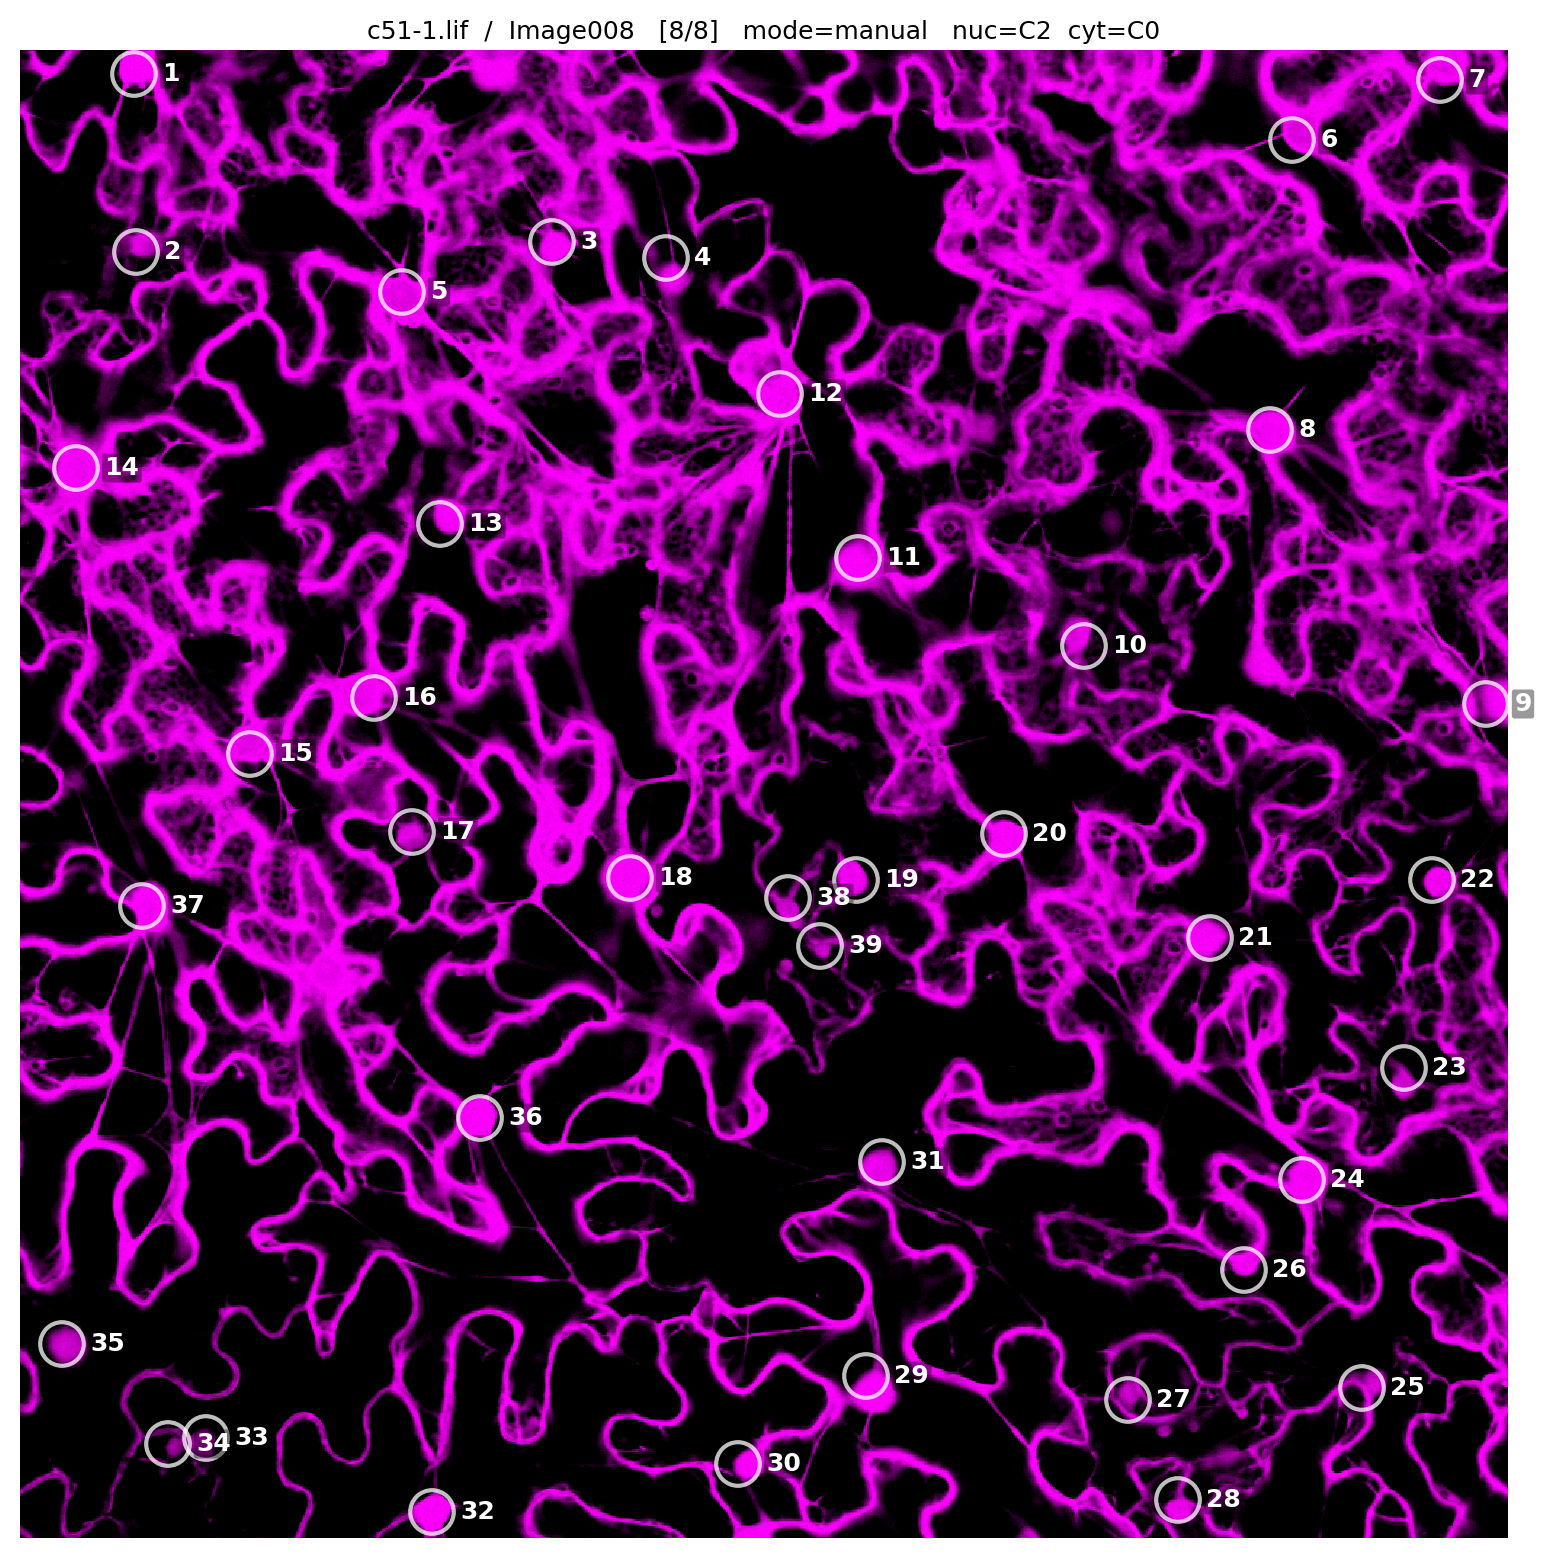

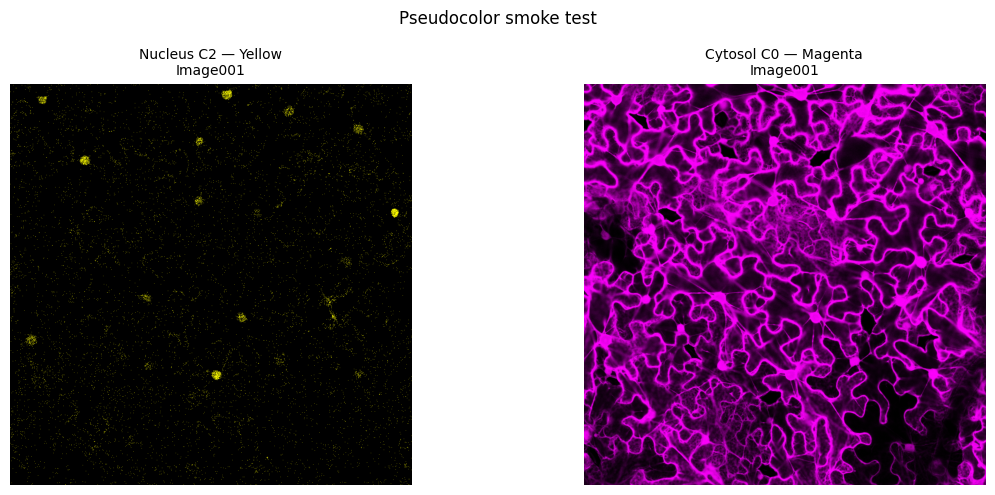


Running quick Cellpose test (protoplast config)…
10:51:33  INFO      lif_analysis — Cellpose [smoke-test]  model=cyto3  diam=100px  shape=(1024, 1024)


AttributeError: module 'cellpose.models' has no attribute 'Cellpose'

In [19]:
# ─── Smoke test — no GUI required ────────────────────────────────────────────
import warnings; warnings.filterwarnings("ignore")

print("=== SMOKE TEST ===")
print(f"readlif:  {HAS_READLIF}")
print(f"cellpose: {HAS_CELLPOSE}")
print(f"ipympl:   {HAS_IPYMPL}")
print()

# 1. Load first item
loader_test = LifLoader(CONFIG["input_path"], CONFIG["z_projection"])
print(f"Items found: {len(loader_test)}")
if len(loader_test) == 0:
    print("No items found — check CONFIG['input_path']")
else:
    it    = loader_test[0]
    print(f"First item: {loader_test.label(it)}")
    print(f"  Channels: {it['n_channels']}  Shape: {it['width']}x{it['height']}")

    chs   = loader_test.get_channels(it)
    print(f"  Loaded channels: {list(chs.keys())}")

    nuc_ch = CONFIG["default_nucleus_channel"]
    cyt_ch = CONFIG["default_cytosol_channel"]

    arr_n = chs.get(nuc_ch)
    arr_c = chs.get(cyt_ch)

    if arr_n is not None:
        vmin, vmax = auto_bc(arr_n)
        yellow = to_yellow(arr_n, vmin, vmax)
        print(f"  Nuclear channel C{nuc_ch}: dtype={arr_n.dtype}  "
              f"range=[{arr_n.min()},{arr_n.max()}]  "
              f"auto-bc=[{vmin:.0f},{vmax:.0f}]  "
              f"yellow shape={yellow.shape}")

    if arr_c is not None:
        vmin, vmax = auto_bc(arr_c)
        magenta = to_magenta(arr_c, vmin, vmax)
        print(f"  Cytosol channel C{cyt_ch}: dtype={arr_c.dtype}  "
              f"range=[{arr_c.min()},{arr_c.max()}]  "
              f"auto-bc=[{vmin:.0f},{vmax:.0f}]  "
              f"magenta shape={magenta.shape}")

    # 2. Quick pseudocolor plot (no widget)
    %matplotlib inline
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if arr_n is not None:
        vmin, vmax = auto_bc(arr_n)
        axes[0].imshow(to_yellow(arr_n, vmin, vmax))
        axes[0].set_title(f"Nucleus C{nuc_ch} — Yellow\n{it['series_name']}", fontsize=10)
        axes[0].axis("off")

    if arr_c is not None:
        vmin, vmax = auto_bc(arr_c)
        axes[1].imshow(to_magenta(arr_c, vmin, vmax))
        axes[1].set_title(f"Cytosol C{cyt_ch} — Magenta\n{it['series_name']}", fontsize=10)
        axes[1].axis("off")

    fig.suptitle("Pseudocolor smoke test", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 3. Cellpose quick test
    if HAS_CELLPOSE and arr_c is not None:
        print("\nRunning quick Cellpose test (protoplast config)…")
        mode = CONFIG["default_mode"]
        cfg  = CONFIG["cellpose_protoplast"] if mode == "protoplast" \
               else CONFIG["cellpose_epidermal"]
        result = run_cellpose(arr_c, cfg, label="smoke-test")
        print(f"  Cellpose result: {result['count']} cells detected")
    else:
        print("\nCellpose test skipped (not installed or no cytosol channel).")

print("\n=== SMOKE TEST COMPLETE ===")


## Dataset Overview

Run to print a summary of all discovered LIF series.


In [ ]:
# ─── Dataset summary table ───────────────────────────────────────────────────
try:
    loader_summary = LifLoader(CONFIG["input_path"])
    df_summary = loader_summary.summary_df()
    print(f"Total series: {len(df_summary)}")
    display(df_summary)
except Exception as exc:
    print(f"Could not load: {exc}")


## Limitations & Future Improvements

### Current limitations

| Area | Limitation |
|------|-----------|
| **Time-lapse** | Only T=0 is processed; multi-timepoint analysis is not supported |
| **Multi-channel overlay** | The viewer shows one channel at a time; composite RGB views are not implemented |
| **Cellpose GPU** | GPU acceleration is disabled by default; toggle `"gpu": True` in CONFIG if CUDA is available |
| **Napari integration** | Not included; would provide superior pan/zoom for large images but adds significant dependency complexity |
| **Autofocus / quality filter** | No automated detection of blurry or out-of-focus images |
| **Batch channel assignment** | Channels must be assigned per-item if they vary across files |
| **Epidermal cell wall channel** | If a dedicated cell-wall marker channel exists, boundary-seeded watershed would outperform the cytosol-based approach |

### High-priority future improvements

1. **Composite RGB viewer** — overlay yellow nucleus + magenta cytosol + grayscale DIC in one panel.
2. **Time-lapse support** — step through T frames per series; count per timepoint.
3. **Napari integration** — use napari's Layer system for non-destructive overlay management.
4. **GPU Cellpose** — expose a one-click GPU toggle in the widget header.
5. **Automated focus scoring** — flag low-contrast images before manual counting.
6. **Cell-wall guided epidermal segmentation** — if a C3 cell wall channel is available in `c51-1.lif`, seed watershed on it for improved pavement cell accuracy.
7. **Interactive parameter tuning** — sliders for Cellpose diameter and flow threshold with live re-run.
8. **Export to OMERO** — push results and masks back to a shared microscopy database.

---

*Notebook generated for Demirer Lab — CIS Project, Caltech.
readlif + Cellpose + scikit-image + ipywidgets stack.*
